In [165]:
import tensorflow as tf
print('GPUs Available:', len(tf.config.list_physical_devices('GPU')))

GPUs Available: 1


In [166]:
import argparse
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

In [167]:
COLUMNS = [ "text", "label"]

MAX_VOCAB = 20000
MAX_LEN = 40
EMBED_DIM = 128
path="/mnt/d/Projects/Sentiment_analysis/dataset/train.csv"


def load_data(path):
    df = pd.read_csv(path, encoding="utf-8")
    df = df.dropna(subset=["text", "label"]).reset_index(drop=True)
    return df


In [168]:
# loaded_df = load_data(path)

In [169]:
# loaded_df

In [170]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [171]:
def prepare(df):
    df = df.copy()
    df["clean_text"] = df["text"].apply(clean_text)
    df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
    return df

In [172]:
# prepared_df = prepare(loaded_df)

In [173]:
# prepared_df

In [174]:
def build_model(vocab_size, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
        Bidirectional(LSTM(32, return_sequences=True, dropout=0.3)),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(32, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(num_classes, activation="softmax"),
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    return model

In [175]:
TRAIN_PATH = "/mnt/d/Projects/Sentiment_analysis/dataset/train.csv"  # <-- Update this with your actual file path
TEST_PATH = "/mnt/d/Projects/Sentiment_analysis/dataset/test.csv"                           # <-- Set to a file path if you have a separate test set
EPOCHS = 15
BATCH_SIZE = 64

# --- Data Loading & Splitting ---
train_df = prepare(load_data(TRAIN_PATH))

if TEST_PATH:
    test_df = prepare(load_data(TEST_PATH))
else:
    train_df, test_df = train_test_split(
        train_df, test_size=0.2, random_state=42, stratify=train_df["label"]
    )

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
print(train_df["label"].value_counts(), "\n")


Train size: 25000, Test size: 25000
label
negative    12476
positive    12475
neutral        49
Name: count, dtype: int64 



In [176]:
# --- Label encoding ---
le = LabelEncoder()
y_train_int = le.fit_transform(train_df["label"])
y_test_int = le.transform(test_df["label"])
num_classes = len(le.classes_)
y_train = to_categorical(y_train_int, num_classes)
y_test = to_categorical(y_test_int, num_classes)

In [177]:
# --- Tokenization ---
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["clean_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["clean_text"])
X_test_seq = tokenizer.texts_to_sequences(test_df["clean_text"])

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

In [178]:
# --- Class weights (dataset is rarely balanced) ---
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_int), y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights))

In [191]:

# --- Model ---
model = build_model(vocab_size, num_classes)

model.summary()

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=None,
    callbacks=[early_stop],
)

/home/gagan/ml/tf/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_12         │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15


/home/gagan/ml/tf/lib/python3.12/site-packages/keras/src/layers/layer.py:1035: UserWarning: Layer 'global_max_pooling1d_12' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.4693 - loss: 1.3764 - val_accuracy: 0.0000e+00 - val_loss: 1.2357
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5208 - loss: 1.0981 - val_accuracy: 0.0000e+00 - val_loss: 1.1113
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5813 - loss: 0.9384 - val_accuracy: 0.5944 - val_loss: 0.8607
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7387 - loss: 0.7420 - val_accuracy: 0.6860 - val_loss: 0.7658
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8066 - loss: 0.6100 - val_accuracy: 0.5720 - val_loss: 0.9347
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8418 - loss: 0.5222 - val_accuracy: 0.6820 - val_loss: 0.7686
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8620 - loss: 0.4683 - val_accuracy: 0.6268 - val_loss: 0.8949



Test Accuracy: 0.7402
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.77      0.75     12478
     neutral       0.00      0.00      0.00        57
    positive       0.76      0.71      0.73     12465

    accuracy                           0.74     25000
   macro avg       0.49      0.49      0.49     25000
weighted avg       0.74      0.74      0.74     25000



/home/gagan/ml/tf/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gagan/ml/tf/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gagan/ml/tf/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Saved confusion_matrix_dl.png


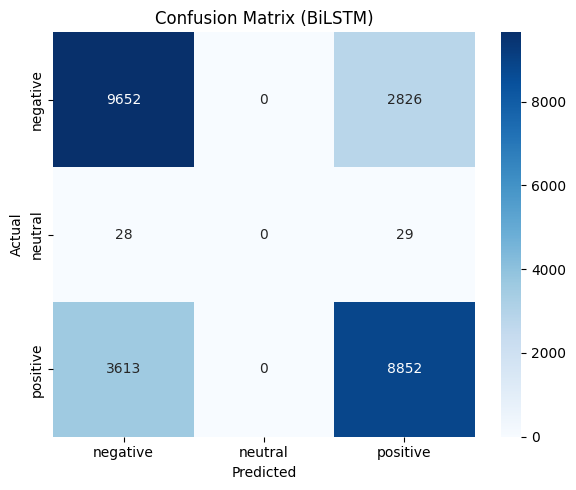

In [192]:
# --- Evaluation ---
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {acc:.4f}")

preds_prob = model.predict(X_test)
preds_int = np.argmax(preds_prob, axis=1)
preds_labels = le.inverse_transform(preds_int)

print("\nClassification Report:")
print(classification_report(test_df["label"], preds_labels))

cm = confusion_matrix(test_df["label"], preds_labels, labels=le.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (BiLSTM)")
plt.tight_layout()
plt.savefig("confusion_matrix_dl.png", dpi=150)
print("Saved confusion_matrix_dl.png")
plt.show() 

Saved training_curves.png


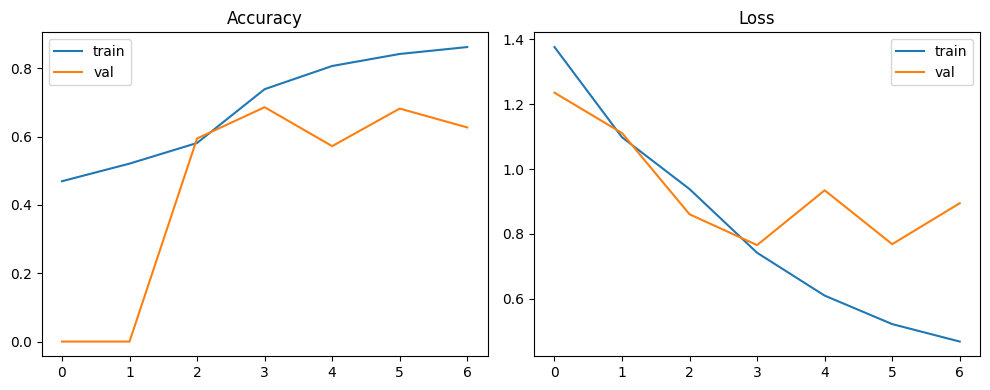

In [193]:
# --- Training curves ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
print("Saved training_curves.png")
plt.show()

In [ ]:
# --- Save model + tokenizer for reuse ---
# model.save("bilstm_sentiment_model.keras")
# import pickle
# with open("tokenizer.pkl", "wb") as f:
#     pickle.dump(tokenizer, f)
# with open("label_encoder.pkl", "wb") as f:
#     pickle.dump(le, f)
# print("Saved model, tokenizer, and label encoder.")

Saved model, tokenizer, and label encoder.


In [190]:
# --- Sample predictions ---
sample_texts = [
    "he is doing some work",
    "This game is absolutely terrible, waste of money",
    "Just chilling, nothing special happening today",
]
cleaned = [clean_text(t) for t in sample_texts]
seq = tokenizer.texts_to_sequences(cleaned)
padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
sample_preds = le.inverse_transform(np.argmax(model.predict(padded), axis=1))
for t, p in zip(sample_texts, sample_preds):
    print(f"[{p}] {t}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[positive] he is doing some work
[negative] This game is absolutely terrible, waste of money
[positive] Just chilling, nothing special happening today


In [184]:
print(train_df["label"].value_counts())

label
negative    12476
positive    12475
neutral        49
Name: count, dtype: int64
